In [ ]:
import time
start_time = time.time()

# Ghana Rainfall Forecast

**Author:** Iman Ngwepe-Ntshibida  
**Date:** Oct 2025  

## Project Overview

Machine learning project predicting rainfall intensity in Ghana using indigenous meteorological and geographical data. Implements multiple algorithms and explainability techniques to classify rainfall into categories (NORAIN, MEDIUMRAIN, HEAVYRAIN, SMALLRAIN) to support agricultural planning.

In [ ]:
!pip install catboost

In [ ]:
!pip install lime

In [ ]:
# Install the correct converter for XGBoost
!pip install onnxmltools

### 1.Import Libraries

In [ ]:
# Core Python & System
import os
import pandas as pd
import numpy as np
np.random.seed(42)

# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('ggplot')

# Scikit-Learn Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ensemble Machine Learning Models
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Scikit-Learn Model Selection & Evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Python Utilities
# Compute class weights
from collections import Counter

# Model Explainability & Interpretability
import shap
import lime
import lime.lime_tabular

# ONNX Model Conversion
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
import onnx

# System Configuration
import warnings
warnings.filterwarnings('ignore')

### 2.Load Data

In [ ]:

# Read files
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)

# Inspect columns
train.head()


Train shape: (10928, 12)
Test shape: (2732, 11)


,ID,user_id,confidence,predicted_intensity,community,district,prediction_time,indicator,indicator_description,time_observed,Target,forecast_length
0,ID_KwcTp_12,11,0.3,0.0,Tumfa,atiwa_west,2025-05-30 11:09:33,NaN,NaN,NaN,MEDIUMRAIN,12
1,ID_K9vWT_12,17,0.3,0.0,Kwabeng,atiwa_west,2025-05-30 11:09:35,NaN,NaN,NaN,HEAVYRAIN,12
2,ID_AIQg3_12,19,0.3,0.0,Akropong,atiwa_west,2025-05-30 11:09:47,NaN,NaN,NaN,MEDIUMRAIN,12
3,ID_px4yf_12,23,0.3,0.0,Asamama,atiwa_west,2025-05-30 11:16:33,NaN,NaN,NaN,HEAVYRAIN,12
4,ID_QYYmK_12,23,0.3,0.0,Asamama,atiwa_west,2025-05-30 11:16:55,NaN,NaN,NaN,HEAVYRAIN,12


## 3.Data Wrangling

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10928 entries, 0 to 10927
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     10928 non-null  object 
 1   user_id                10928 non-null  int64  
 2   confidence             10928 non-null  float64
 3   predicted_intensity    10928 non-null  float64
 4   community              10928 non-null  object 
 5   district               10928 non-null  object 
 6   prediction_time        10928 non-null  object 
 7   indicator              503 non-null    object 
 8   indicator_description  346 non-null    object 
 9   time_observed          72 non-null     object 
 10  Target                 10928 non-null  object 
 11  forecast_length        10928 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 1.0+ MB



### 3.1 Time Features Engineering



In [ ]:
def parse_time_features(df, time_col='prediction_time'):
    df = df.copy()
    if time_col in df.columns:
        dt = pd.to_datetime(df[time_col].astype(str), dayfirst=True, errors='coerce')
        df['pred_hour'] = dt.dt.hour
        df['pred_dow'] = dt.dt.dayofweek
        df['pred_date'] = dt.dt.date.astype('str')
        df['is_weekend'] = dt.dt.dayofweek.isin([5, 6]).astype(int)
    return df

# Extract time features first
train = parse_time_features(train)
test = parse_time_features(test)

# Drop the columns from both DataFrames
drop_cols = ['prediction_time', 'time_observed', 'indicator_description']
train = train.drop(columns=drop_cols, errors='ignore')
test = test.drop(columns=drop_cols, errors='ignore')

# Fetch feature columns
feature_cols = [c for c in train.columns if c not in ['Target', 'ID']]

numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train[c])]
cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(train[c])]

print('Numeric features:', numeric_cols)
print('Categorical features:', cat_cols)

Numeric features: ['user_id', 'confidence', 'predicted_intensity', 'forecast_length', 'pred_hour', 'pred_dow', 'is_weekend']
Categorical features: ['community', 'district', 'indicator', 'pred_date']


### 3.2Text Cleaning - Community

In [ ]:
# Handle text inconsistencies in 'community'

def clean_communities(df, community_col='community'):
    """
    Comprehensive cleaning of Ghanaian community names with proper standardization
    """
    df = df.copy()

    if community_col in df.columns:
        # Convert to string and strip leading/trailing spaces
        df[community_col] = df[community_col].astype(str).str.strip()

        # Replace multiple spaces with single space
        df[community_col] = df[community_col].str.replace(r'\s+', ' ', regex=True)

        # Convert to proper title case (first letter of each word capitalized)
        df[community_col] = df[community_col].str.title()

        # Specific standardizations for Ghanaian communities
        community_mapping = {
            # Standardize Assin district communities
            'Atonsu': 'Assin Atonsu',
            'Assin Atonsu': 'Assin Atonsu',

            # Standardize Odumasi variations (but keep distinct ones separate)
            'Odumasi': 'Odumasi',  # Generic Odumasi
            'Foso Odumasi': 'Foso Odumasi',
            'Assin Foso Odumasi': 'Assin Foso Odumasi',
            'Odumasi Adansi': 'Odumasi Adansi',  # Different from Assin Odumasi

            # Standardize other communities
            'Akwaduuso': 'Akwaduuso',
            'Akropong': 'Akropong',
            'Asunafo': 'Asunafo',
            'Tumfa': 'Tumfa',
            'Kwabeng': 'Kwabeng',
            'Banso': 'Banso',
            'Abomosu': 'Abomosu',
            'Mouso': 'Mouso',
            'Amonom': 'Amonom',
            'Apampatia': 'Apampatia',
            'Awenare': 'Awenare',
            'Asamama': 'Asamama',
            'Assin Brofoyedur': 'Assin Brofoyedur',
            'Assin Aponsie': 'Assin Aponsie',
            'Assin Nyankomasi': 'Assin Nyankomasi',
            'Assin Wurakese': 'Assin Wurakese',
            'Mampamhwe': 'Mampamhwe',

            # New communities from test set
            'Jimiso': 'Jimiso',
            'Asonkore': 'Asonkore',
            'Dompim': 'Dompim',
            'Domeabra': 'Domeabra'
        }

        # Apply the mapping
        df[community_col] = df[community_col].replace(community_mapping)

    return df

# Apply cleaning
train = clean_communities(train)
test = clean_communities(test)

# Verify results
print(train.community.unique())
print(test.community.unique())

['Tumfa' 'Kwabeng' 'Akropong' 'Asamama' 'Akwaduuso' 'Banso' 'Awenare'
 'Mouso' 'Abomosu' 'Foso Odumasi' 'Amonom' 'Asunafo' 'Apampatia'
 'Assin Atonsu' 'Odumasi' 'Assin Wurakese' 'Odumasi Adansi'
 'Assin Aponsie' 'Assin Nyankomasi' 'Assin Foso Odumasi'
 'Assin Mesre Nyame' 'Assin Brofoyedur' 'Mampamhwe']
['Assin Brofoyedur' 'Akwaduuso' 'Awenare' 'Amonom' 'Asunafo'
 'Odumasi Adansi' 'Odumasi' 'Mampamhwe' 'Akropong' 'Assin Atonsu'
 'Assin Aponsie' 'Foso Odumasi' 'Assin Nyankomasi' 'Kwabeng' 'Asamama'
 'Jimiso' 'Asonkore' 'Dompim' 'Assin Foso Odumasi' 'Assin Wurakese'
 'Tumfa' 'Abomosu' 'Mouso' 'Banso' 'Domeabra']


## 4.Data Exploration


`Target - Class Balance`


Rain Type Distribution:
 Target
NORAIN        87.96
MEDIUMRAIN     6.96
HEAVYRAIN      2.88
SMALLRAIN      2.20
Name: proportion, dtype: float64


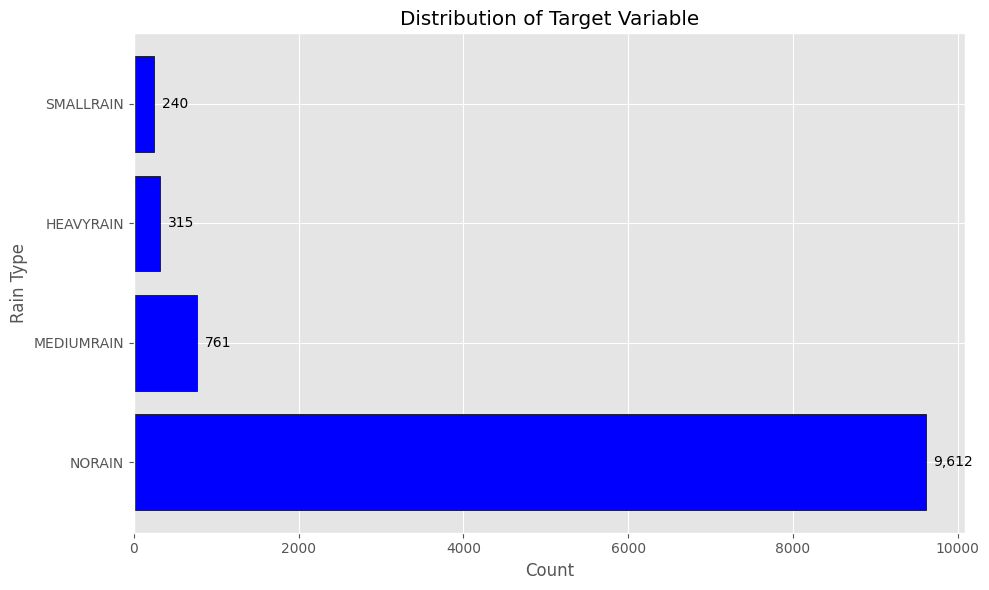

In [ ]:
# Show class distribution
target_dist = train.Target.value_counts(normalize=True) * 100
print('Rain Type Distribution:\n', target_dist.round(2))

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
target_counts = train['Target'].value_counts()

# Sort from highest to lowest (largest at top)
target_counts_sorted = target_counts.sort_values(ascending=False)

# Create horizontal bar plot
bars = plt.barh(range(len(target_counts_sorted)), target_counts_sorted.values,
                color='blue', edgecolor='black')

plt.title('Distribution of Target Variable')
plt.xlabel('Count')
plt.ylabel('Rain Type')

# Set y-axis labels
plt.yticks(range(len(target_counts_sorted)), target_counts_sorted.index)

# Add count labels on bars (no percentages)
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + max(target_counts_sorted.values) * 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}',
             va='center', ha='left', fontsize=10)

plt.tight_layout();

Severe class imbalance: NORAIN" predictions dominate the dataset, comprising 88% of all observations, while rainfall categories are critically underrepresented at 2-7% each

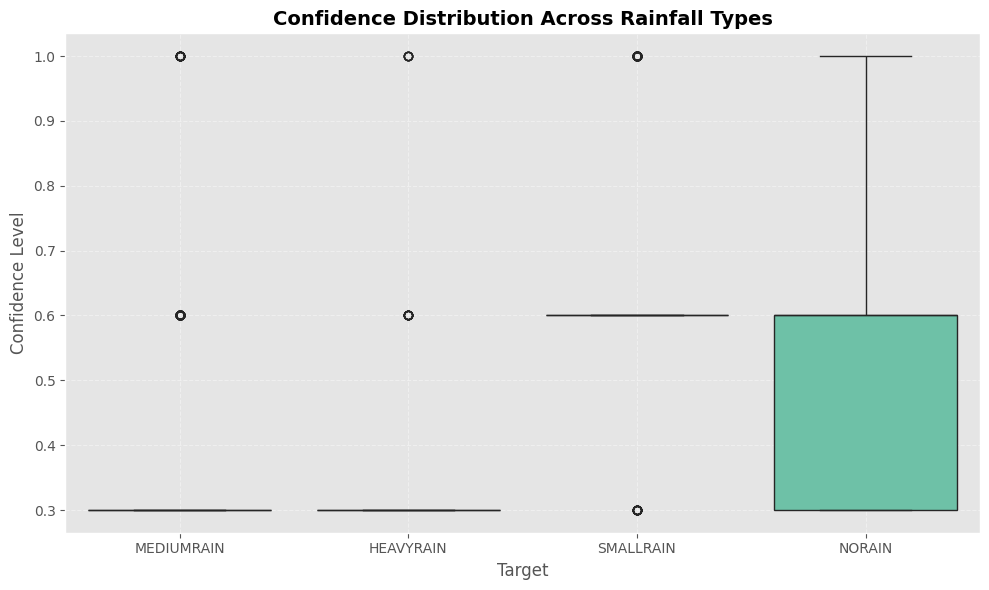

In [ ]:
# How does Confidence vary across different rainfall types
plt.figure(figsize=(10,6))
sns.boxplot(x='Target', y='confidence', data=train, palette='mako')

plt.title('Confidence Distribution Across Rainfall Types', fontsize=14, fontweight='bold')
plt.xlabel('Target', fontsize=12)
plt.ylabel('Confidence Level', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout();

NORAIN has the highest prediction confidence.

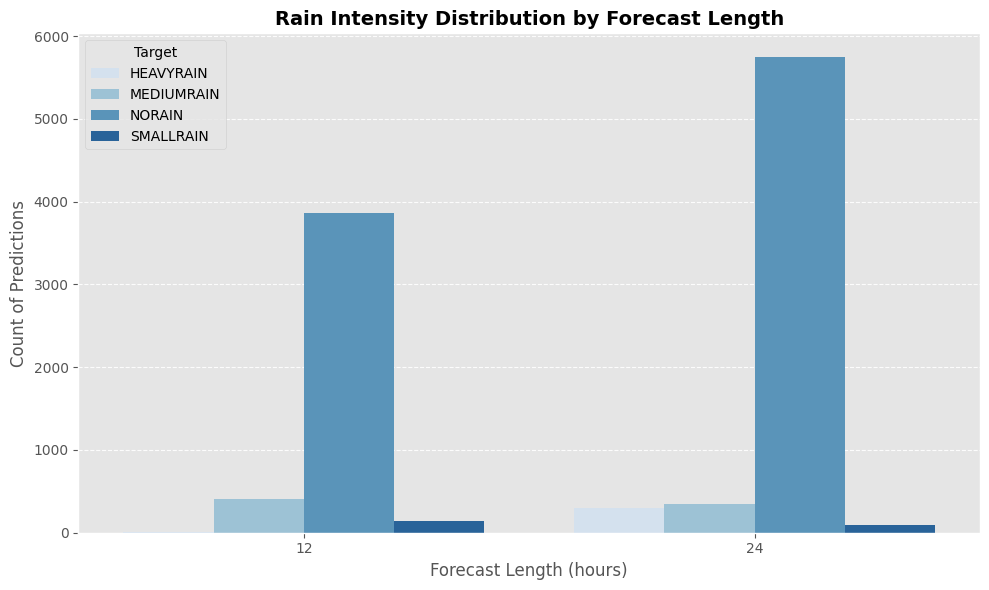

In [ ]:
# How does forecast length (12 vs. 24 hours) affect the predicted rainfall intensity

# Frequency of Target per forecast length
rain_dist = (
    train.groupby(['forecast_length', 'Target'])
    .size()
    .reset_index(name='count')
)

# Bar chart
plt.figure(figsize=(10,6))
sns.barplot(
    data=rain_dist,
    x='forecast_length',
    y='count',
    hue='Target',
    palette='Blues'
)
plt.title('Rain Intensity Distribution by Forecast Length', fontsize=14, fontweight='bold')
plt.xlabel('Forecast Length (hours)', fontsize=12)
plt.ylabel('Count of Predictions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout();


The 12-hour forecast almost never predicts heavy rain while the 24-hour forecast is more likely to predicts no rain.

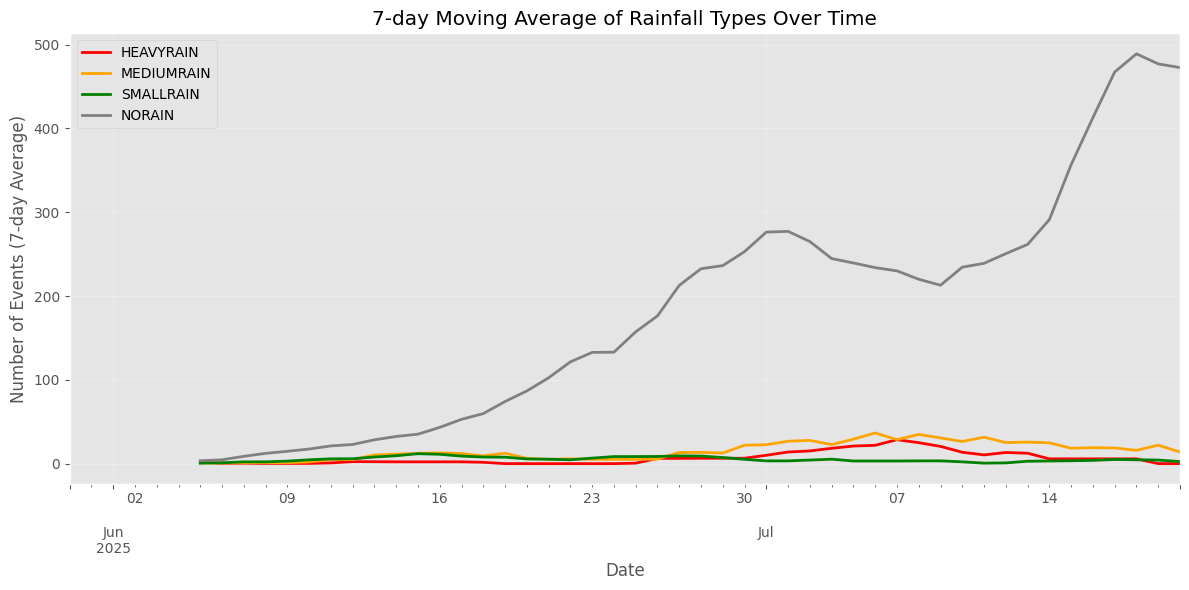

In [ ]:
# Individual Rainfall Types Over Time
plt.figure(figsize=(12, 6))

train_date = train.copy()
train_date['pred_date'] = pd.to_datetime(train_date['pred_date'])
train_date = train_date.set_index('pred_date')

# Plot each rain type separately
rain_types = ['HEAVYRAIN', 'MEDIUMRAIN', 'SMALLRAIN', 'NORAIN']
colors = ['red', 'orange', 'green', 'grey']

for i, rain_type in enumerate(rain_types):
    rain_events = (train_date['Target'] == rain_type).resample('D').sum()
    rain_events.rolling(7).mean().plot(linewidth=2, label=rain_type, color=colors[i])

plt.title('7-day Moving Average of Rainfall Types Over Time')
plt.ylabel('Number of Events (7-day Average)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout();

There were more records of 'NORAIN' instances than any other rain type.

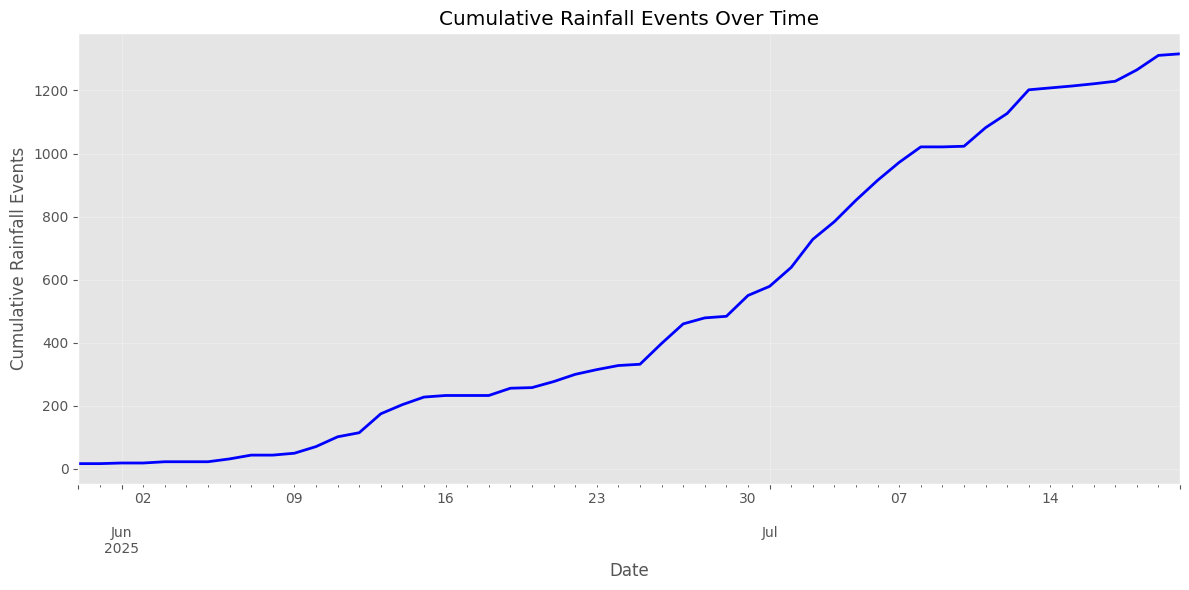

In [ ]:

# Cumulative Rainfall Events Over Time
plt.figure(figsize=(12, 6))

train_date = train.copy()
train_date['pred_date'] = pd.to_datetime(train_date['pred_date'])
train_date = train_date.set_index('pred_date')

# Cumulative count of rainfall events
rainfall_events = (train_date['Target'] != 'NORAIN').resample('D').sum()
cumulative_rain = rainfall_events.cumsum()

cumulative_rain.plot(color='blue', linewidth=2)
plt.title('Cumulative Rainfall Events Over Time')
plt.ylabel('Cumulative Rainfall Events')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout();

Cumulative rainfall predictions show consistent growth in traditional forecasting participation.

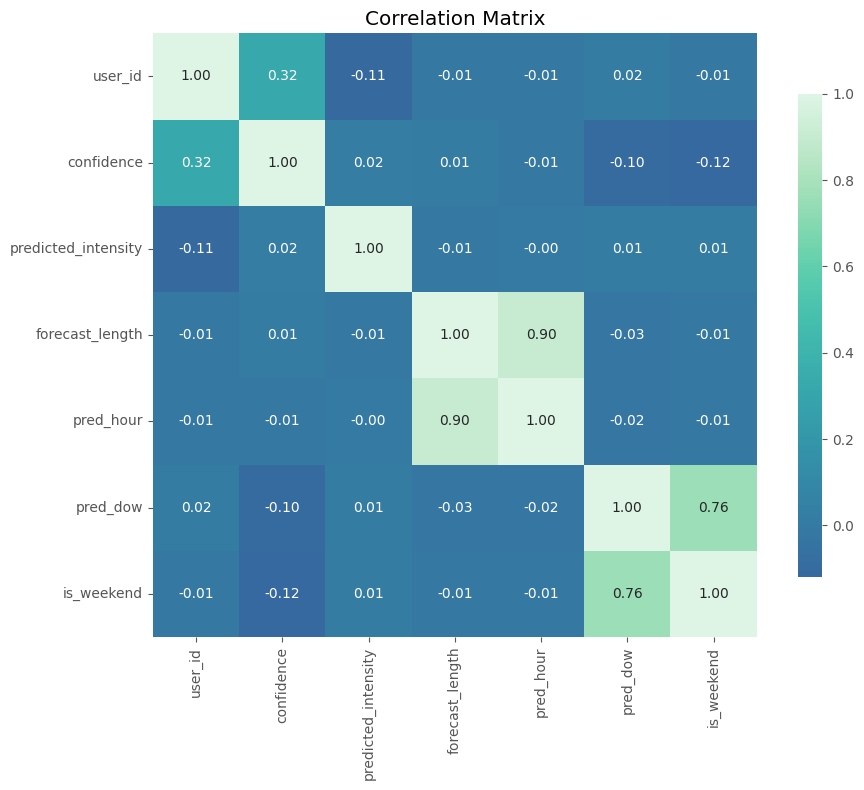

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10, 8))

numerical_df = train.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='mako',
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix')
plt.tight_layout();

Strong multicollinearity detected between temporal features, while predictive variables show limited linear relationship.


In [ ]:
# District Distribution Analysis
district_counts = train['district'].value_counts()
district_counts

,count
district,
atiwa_west,4877
assin_fosu,4815
obuasi_east,1236



 TOP 10 FARMERS - DISTRICT BREAKDOWN:
Farmer 18: 1333 predictions | District: assin_fosu   | Community: Akwaduuso
Farmer 47: 1182 predictions | District: assin_fosu   | Community: Foso Odumasi
Farmer 23: 1130 predictions | District: atiwa_west   | Community: Asamama
Farmer 66: 853 predictions | District: assin_fosu   | Community: Assin Nyankomasi
Farmer 27: 632 predictions | District: atiwa_west   | Community: Akropong
Farmer 53: 569 predictions | District: atiwa_west   | Community: Tumfa
Farmer 62: 479 predictions | District: assin_fosu   | Community: Assin Atonsu
Farmer 22: 457 predictions | District: atiwa_west   | Community: Awenare
Farmer  7: 434 predictions | District: atiwa_west   | Community: Abomosu
Farmer 81: 399 predictions | District: obuasi_east  | Community: Odumasi


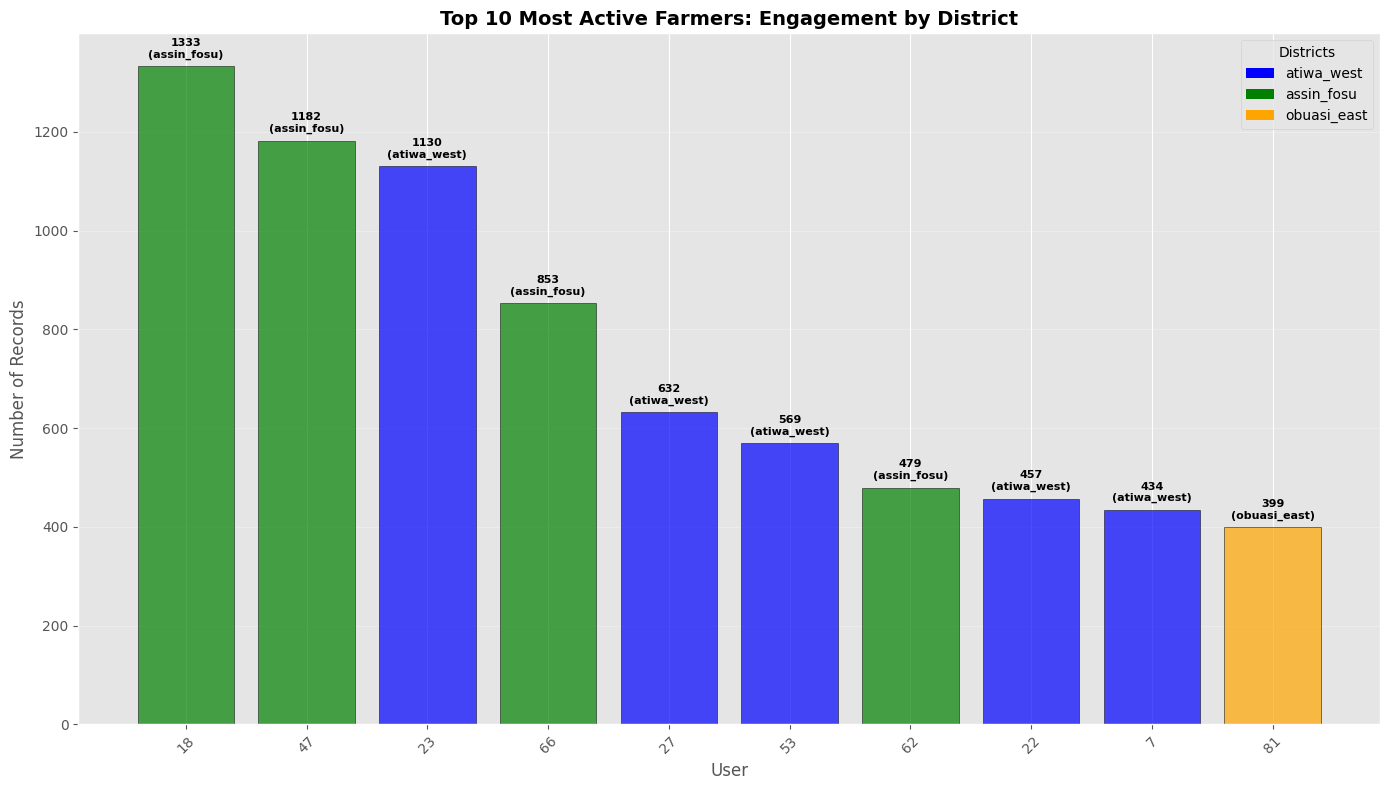

In [ ]:
# User Activity Analysis with District Information
plt.figure(figsize=(14, 8))

# Count predictions per user and get their districts
user_activity = train['user_id'].value_counts().head(10)

# Get district information for top 10 users
top_users_districts = train[train['user_id'].isin(user_activity.index)].groupby('user_id').agg({
    'district': 'first',  # one user per district
    'community': 'first'  # one user per community
}).reindex(user_activity.index)

# Create color mapping for districts
district_colors = {
    'atiwa_west': 'blue',
    'assin_fosu': 'green',
    'obuasi_east': 'orange'
}

# Create the bar chart with district-based coloring
bars = plt.bar(range(len(user_activity)), user_activity.values,
               color=[district_colors.get(d, 'gray') for d in top_users_districts['district']],
               alpha=0.7, edgecolor='black')

plt.title('Top 10 Most Active Farmers: Engagement by District', fontsize=14, fontweight='bold')
plt.xlabel('User')
plt.ylabel('Number of Records')
plt.xticks(range(len(user_activity)), user_activity.index, rotation=45)

# Add value labels and district information on bars
for i, (count, user_id) in enumerate(zip(user_activity.values, user_activity.index)):
    district = top_users_districts.loc[user_id, 'district']
    community = top_users_districts.loc[user_id, 'community']

    plt.text(i, count + max(user_activity.values) * 0.01, f'{count}\n({district})',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')

# Add legend for districts
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=district)
                   for district, color in district_colors.items()]
plt.legend(handles=legend_elements, title='Districts', loc='upper right')

plt.tight_layout();

# Print detailed breakdown
print('\n TOP 10 FARMERS - DISTRICT BREAKDOWN:')
for user_id in user_activity.index:
    district = top_users_districts.loc[user_id, 'district']
    community = top_users_districts.loc[user_id, 'community']
    predictions = user_activity[user_id]
    print(f"Farmer {user_id:2d}: {predictions:3d} predictions | District: {district:12} | Community: {community}")


Farmers #18, #47 and #23 demonstrate significantly higher engagement levels than the rest of other users.With #18 and #47 coming from the same district but different community.

<Figure size 1200x800 with 0 Axes>

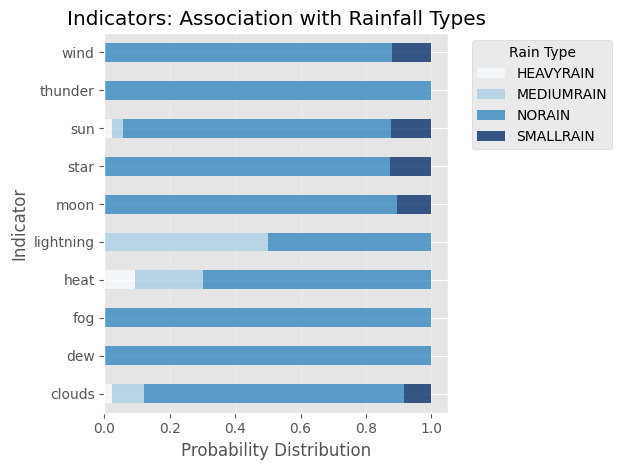

In [ ]:
# Indigenous Indicators and Their Rain Type Associations
plt.figure(figsize=(12, 8))

# Get indicator-rain type relationships
indicator_rain = train[train['indicator'].notna()].groupby('indicator')['Target'].value_counts(normalize=True).unstack()

# Create horizontal stacked bar chart with Blues palette
indicator_rain.plot(kind='barh', stacked=True, cmap='Blues', alpha=0.8)

plt.title('Indicators: Association with Rainfall Types')
plt.ylabel('Indicator')
plt.xlabel('Probability Distribution')
plt.legend(title='Rain Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout();

While each traditional weather indicator displays distinct rainfall probability patterns, all indicators maintain a consistent 'NORAIN' component. Lighting has a higher probability of MEDIUMRAIN prediction. While sun, heat and clouds show some probabilities of HEAVYRAIN.

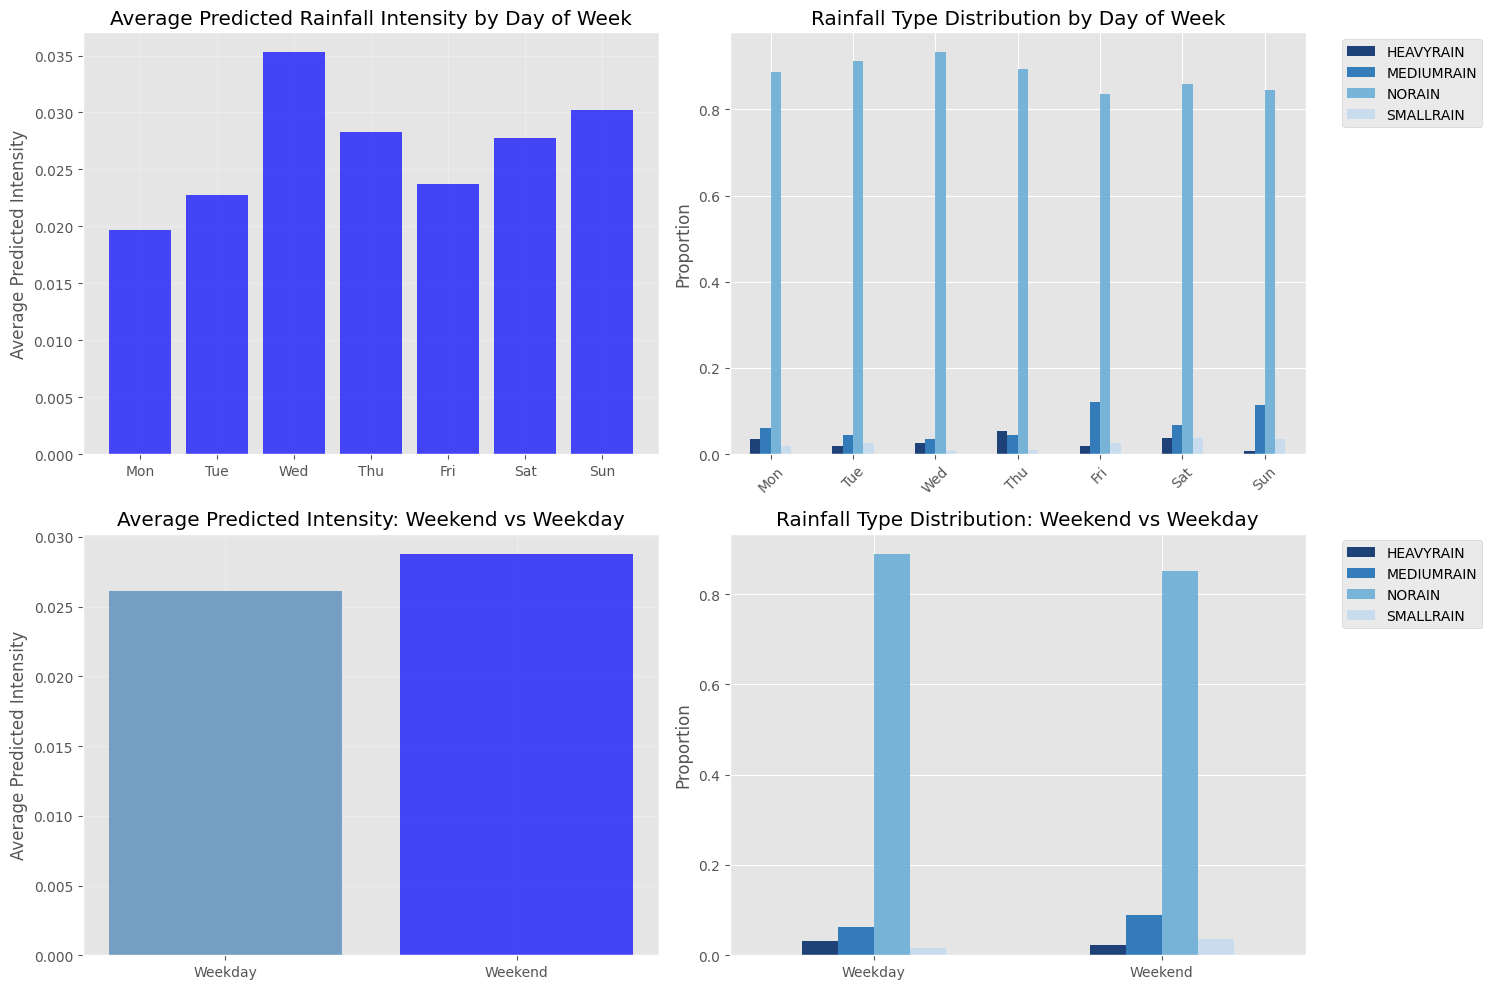

In [ ]:
# Day of Week and Weekend Effects on Rainfall
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Average Predicted Intensity by Day of Week
intensity_by_dow = train.groupby('pred_dow')['predicted_intensity'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0,0].bar(day_names, intensity_by_dow.values, color='blue', alpha=0.7)
axes[0,0].set_title('Average Predicted Rainfall Intensity by Day of Week')
axes[0,0].set_ylabel('Average Predicted Intensity')
axes[0,0].grid(True, alpha=0.3)

# 2. Rainfall Type Distribution by Day of Week
rain_by_dow = pd.crosstab(train['pred_dow'], train['Target'], normalize='index')
rain_by_dow.index = day_names
colors = ['#08306b', '#2171b5', '#6baed6', '#c6dbef']  # Dark to light blues
# Plot with explicit color mapping
rain_by_dow.plot(kind='bar', ax=axes[0,1], color=colors, alpha=0.9)
axes[0,1].set_title('Rainfall Type Distribution by Day of Week')
axes[0,1].set_ylabel('Proportion')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Weekend vs Weekday Intensity Comparison
weekend_intensity = train.groupby('is_weekend')['predicted_intensity'].mean()
axes[1,0].bar(['Weekday', 'Weekend'], weekend_intensity.values,
              color=['steelblue', 'blue'], alpha=0.7)
axes[1,0].set_title('Average Predicted Intensity: Weekend vs Weekday')
axes[1,0].set_ylabel('Average Predicted Intensity')
axes[1,0].grid(True, alpha=0.3)

# 4. Rainfall Type Distribution: Weekend vs Weekday
weekend_rain = pd.crosstab(train['is_weekend'], train['Target'], normalize='index')
weekend_rain.index = ['Weekday', 'Weekend']
colors = ['#08306b', '#2171b5', '#6baed6', '#c6dbef']  # Dark to light blues

# Plot on axes[1,1] instead
weekend_rain.plot(kind='bar', ax=axes[1,1], color=colors, alpha=0.9)

# Set properties on the same axis
axes[1,1].set_title('Rainfall Type Distribution: Weekend vs Weekday')
axes[1,1].set_ylabel('Proportion')
axes[1,1].set_xlabel('')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout();

Wednesday shows significantly higher predicted rainfall intensity, suggesting mid-week atmospheric patterns favor heavier precipitation, while weekends also demonstrate elevated intensity levels potentially linked to urban activity cycles or weekly weather systems; despite these variations, dry conditions remain consistently dominant across all time periods.


## 5.Preprocessing

In [ ]:
# Fit on feature columns only

# Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    verbose_feature_names_out=False  # Removes the prefixes
)

preprocessor.fit(train[feature_cols])

# Transform both datasets using only feature columns
train_pro = preprocessor.transform(train[feature_cols])
test_pro = preprocessor.transform(test[feature_cols])

print(f'Processed train shape: {train_pro.shape}')
print(f'Processed test shape: {test_pro.shape}')

# Convert to DataFrame
feature_names = preprocessor.get_feature_names_out()
train_df = pd.DataFrame(train_pro, columns=feature_names)
test_df = pd.DataFrame(test_pro, columns=feature_names)

# Add Target separately
train_df['Target'] = train['Target'].values

print('Train DataFrame columns:', train_df.columns.tolist())

Processed train shape: (10928, 94)
Processed test shape: (2732, 94)
Train DataFrame columns: ['user_id', 'confidence', 'predicted_intensity', 'forecast_length', 'pred_hour', 'pred_dow', 'is_weekend', 'community_Abomosu', 'community_Akropong', 'community_Akwaduuso', 'community_Amonom', 'community_Apampatia', 'community_Asamama', 'community_Assin Aponsie', 'community_Assin Atonsu', 'community_Assin Brofoyedur', 'community_Assin Foso Odumasi', 'community_Assin Mesre Nyame', 'community_Assin Nyankomasi', 'community_Assin Wurakese', 'community_Asunafo', 'community_Awenare', 'community_Banso', 'community_Foso Odumasi', 'community_Kwabeng', 'community_Mampamhwe', 'community_Mouso', 'community_Odumasi', 'community_Odumasi Adansi', 'community_Tumfa', 'district_assin_fosu', 'district_atiwa_west', 'district_obuasi_east', 'indicator_clouds', 'indicator_dew', 'indicator_fog', 'indicator_heat', 'indicator_lightning', 'indicator_moon', 'indicator_star', 'indicator_sun', 'indicator_thunder', 'indicato

## 6.Model Building

In [ ]:
# Data Preparation
X = train_df.drop(columns=['Target'], errors='ignore')
y = train_df['Target']

In [ ]:
# Train/Validation Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
# Encode Target string to numeric
label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_val_numeric = label_encoder.transform(y_val)
y_test_numeric = label_encoder.transform(y_test)

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

class_counts = Counter(y_train)
max_count = max(class_counts.values())
scale_weights = [max_count / class_counts[cls] for cls in label_encoder.classes_]
print("Class weights:", dict(zip(label_encoder.classes_, scale_weights)))

# ===== MODEL PIPELINE =====
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        use_label_encoder=False,
        scale_pos_weight=scale_weights
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200,
        depth=5,
        learning_rate=0.1,
        random_state=42,
        verbose=False,
        auto_class_weights='Balanced'
    )
}

# ===== TRAIN AND EVALUATE ALL MODELS =====
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    start_time = time.time()

    # Train model
    model.fit(X_train, y_train_numeric)

    # Predict on training set
    y_train_pred_numeric = model.predict(X_train)
    y_train_pred = label_encoder.inverse_transform(y_train_pred_numeric)

    # Predict on validation set
    y_val_pred_numeric = model.predict(X_val)
    y_val_pred = label_encoder.inverse_transform(y_val_pred_numeric)

    # Predict on test set
    y_test_pred_numeric = model.predict(X_test)
    y_test_pred = label_encoder.inverse_transform(y_test_pred_numeric)

    # Calculate scores
    train_macro_f1 = f1_score(y_train, y_train_pred, average='macro')
    val_macro_f1 = f1_score(y_val, y_val_pred, average='macro')
    test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')

    # Calculate execution time
    end_time = time.time()
    elapsed_time = end_time - start_time

    # Store results
    results.append({
        'Model': model_name,
        'Train_Macro_F1': train_macro_f1,
        'Validation_Macro_F1': val_macro_f1,
        'Test_Macro_F1': test_macro_f1,
        'Train_Val_Gap': train_macro_f1 - val_macro_f1,
        'Val_Test_Gap': val_macro_f1 - test_macro_f1,
        'Time_Seconds': elapsed_time
    })

    print(f"{model_name} completed in {elapsed_time:.1f} seconds\n")

# ===== COMPARISON SUMMARY =====
print("\nMODEL COMPARISON SUMMARY")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_Macro_F1', ascending=False)
print(results_df.to_string(index=False, float_format='%.4f'))

Label mapping: {'HEAVYRAIN': np.int64(0), 'MEDIUMRAIN': np.int64(1), 'NORAIN': np.int64(2), 'SMALLRAIN': np.int64(3)}
Class weights: {'HEAVYRAIN': 30.601990049751244, 'MEDIUMRAIN': 12.630390143737166, 'NORAIN': 1.0, 'SMALLRAIN': 39.94155844155844}
Training XGBoost...
XGBoost completed in 8.2 seconds

Training LightGBM...
LightGBM completed in 5.1 seconds

Training CatBoost...
CatBoost completed in 3.1 seconds


MODEL COMPARISON SUMMARY
   Model  Train_Macro_F1  Validation_Macro_F1  Test_Macro_F1  Train_Val_Gap  Val_Test_Gap  Time_Seconds
LightGBM          0.9701               0.9276         0.9440         0.0426       -0.0164        5.1194
 XGBoost          0.9784               0.9487         0.9382         0.0297        0.0105        8.2273
CatBoost          0.8107               0.7736         0.7878         0.0371       -0.0142        3.0820


XGBoost has the highest validation performance with minimal overfitting, showing consistency across data splits.


### 6.1 Train On Full Train Set


In [ ]:
import time

# Use the existing label encoder mapping
y_full_numeric = label_encoder.transform(y)
class_names = label_encoder.classes_

print("Class mapping:", dict(zip(range(len(class_names)), class_names)))

X_features = X

# Cross-validation setup
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

# Create a new model with the same configuration
new_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False,
    scale_pos_weight=scale_weights
)

# Cross-validate the new model
print("Starting cross-validation...")
cv_start_time = time.time()

cv_results = cross_validate(new_model, X_features, y_full_numeric,
                          cv=skf, scoring=scoring, n_jobs=-1)

cv_end_time = time.time()
cv_elapsed_time = cv_end_time - cv_start_time

print(' CROSS-VALIDATION RESULTS ')
print(f"Macro F1: {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"Weighted F1: {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")
print(f"Cross-validation completed in {cv_elapsed_time:.1f} seconds")

# Train final model on full data
print("\nTraining final model on full dataset...")
final_start_time = time.time()

final_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False,
    scale_pos_weight=scale_weights
)
final_model.fit(X_features, y_full_numeric)

final_end_time = time.time()
final_elapsed_time = final_end_time - final_start_time

print(f"Final model training completed in {final_elapsed_time:.1f} seconds")
print(f"Total execution time: {cv_elapsed_time + final_elapsed_time:.1f} seconds")

Class mapping: {0: 'HEAVYRAIN', 1: 'MEDIUMRAIN', 2: 'NORAIN', 3: 'SMALLRAIN'}
Starting cross-validation...
 CROSS-VALIDATION RESULTS 
Macro F1: 0.9501 ± 0.0101
Weighted F1: 0.9878 ± 0.0026
Cross-validation completed in 35.0 seconds

Training final model on full dataset...
Final model training completed in 7.6 seconds
Total execution time: 42.5 seconds


### 6.2 Score Model

In [ ]:
# Make predictions on the FULL training dataset (X_features)
y_pred_full_numeric = final_model.predict(X_features)
y_pred_full = label_encoder.inverse_transform(y_pred_full_numeric)

# Verify shapes match
print(f"Shape check:")
print(f"y (true labels) shape: {y.shape}")
print(f"y_pred_full (predictions) shape: {y_pred_full.shape}")

train_macro_f1 = f1_score(y, y_pred_full, average='macro')
train_weighted_f1 = f1_score(y, y_pred_full, average='weighted')

print(f"\nOverall Performance:")
print(f"Macro F1: {train_macro_f1:.4f}")
print(f"Weighted F1: {train_weighted_f1:.4f}")

# Detailed Classification Report
print(f"\nClassification Report:")

print(classification_report(y, y_pred_full, target_names=class_names, digits=4))

# Confusion Matrix with labels
print(f"\n Confusion Matrix (with labels):")
conf_matrix = confusion_matrix(y, y_pred_full)
conf_df = pd.DataFrame(conf_matrix,
                      index=[f'True {name}' for name in class_names],
                      columns=[f'Pred {name}' for name in class_names])
print(conf_df)

# Most common misclassifications
print(f"\n Top Misclasification:")
misclassifications = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and conf_matrix[i, j] > 0:
            misclassifications.append((class_names[i], class_names[j], conf_matrix[i, j]))

# Sort by count and show top 5
misclassifications.sort(key=lambda x: x[2], reverse=True)
for true_class, pred_class, count in misclassifications[:5]:
    true_class_idx = list(class_names).index(true_class)
    percentage = (count / conf_matrix[true_class_idx, :].sum()) * 100
    print(f"True: {true_class:12} → Pred: {pred_class:12} : {count:3d} cases ({percentage:.1f}%)")



Shape check:
y (true labels) shape: (10928,)
y_pred_full (predictions) shape: (10928,)

Overall Performance:
Macro F1: 0.9758
Weighted F1: 0.9930

Classification Report:
              precision    recall  f1-score   support

   HEAVYRAIN     0.9904    0.9873    0.9889       315
  MEDIUMRAIN     0.9904    0.9474    0.9684       761
      NORAIN     0.9933    0.9992    0.9962      9612
   SMALLRAIN     1.0000    0.9042    0.9497       240

    accuracy                         0.9931     10928
   macro avg     0.9935    0.9595    0.9758     10928
weighted avg     0.9931    0.9931    0.9930     10928


 Confusion Matrix (with labels):
                 Pred HEAVYRAIN  Pred MEDIUMRAIN  Pred NORAIN  Pred SMALLRAIN
True HEAVYRAIN              311                1            3               0
True MEDIUMRAIN               1              721           39               0
True NORAIN                   2                6         9604               0
True SMALLRAIN                0                0 

  The model is good at predicting when it won't rain, but often misses actual rain events, in particular little rain. It is better suited for avoiding false alarms than at catching all rainfall.

  Minimal 2.6% performance gap between train and cv f1 scores indicates good generalisation.

## 7.Explain Model

`1. SHAP`

SHAP values shape: (100, 94, 4)
Number of classes: 4

=== GLOBAL FEATURE IMPORTANCE (TOP 10) ===
            feature  importance
            user_id    0.759667
  community_Asamama    0.623733
          pred_hour    0.379884
district_atiwa_west    0.357715
         confidence    0.271853
           pred_dow    0.163040
 community_Akropong    0.110511
  community_Kwabeng    0.069531
   indicator_clouds    0.062887
    forecast_length    0.062668


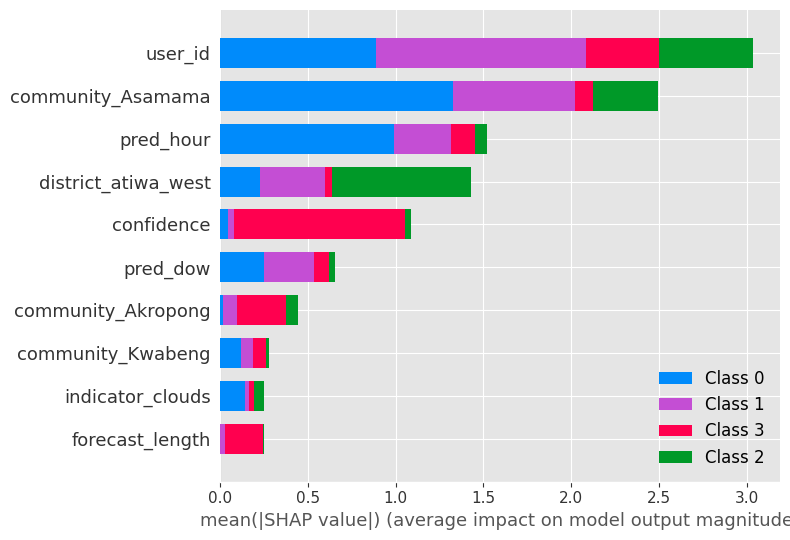


=== FEATURE EFFECTS SUMMARY ===

Feature Impact Directions:
user_id                   NEGATIVE ↓   (corr: -0.780)
community_Asamama         POSITIVE ↑   (corr: +0.947)
pred_hour                 POSITIVE ↑   (corr: +0.924)
district_atiwa_west       NEGATIVE ↓   (corr: -0.510)
confidence                POSITIVE ↑   (corr: +0.776)
pred_dow                  POSITIVE ↑   (corr: +0.820)
community_Akropong        POSITIVE ↑   (corr: +0.706)
community_Kwabeng         POSITIVE ↑   (corr: +0.366)
indicator_clouds          POSITIVE ↑   (corr: +0.889)
forecast_length           NEGATIVE ↓   (corr: -0.867)


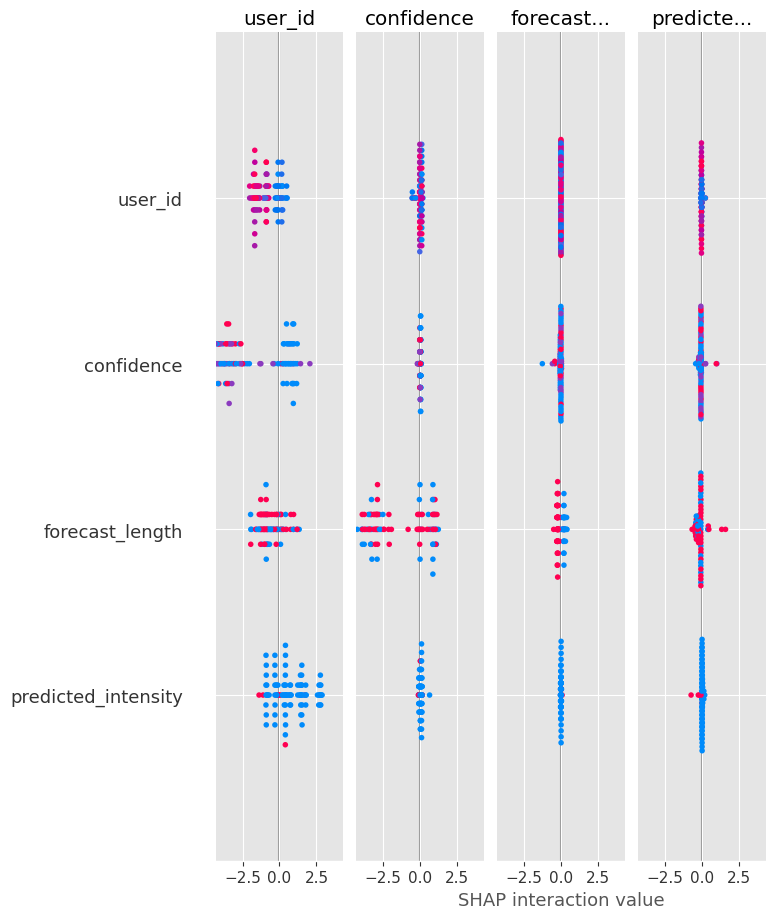


=== INDIVIDUAL PREDICTION EXPLANATIONS (TOP 10) ===

--- Explanation for HEAVYRAIN ---


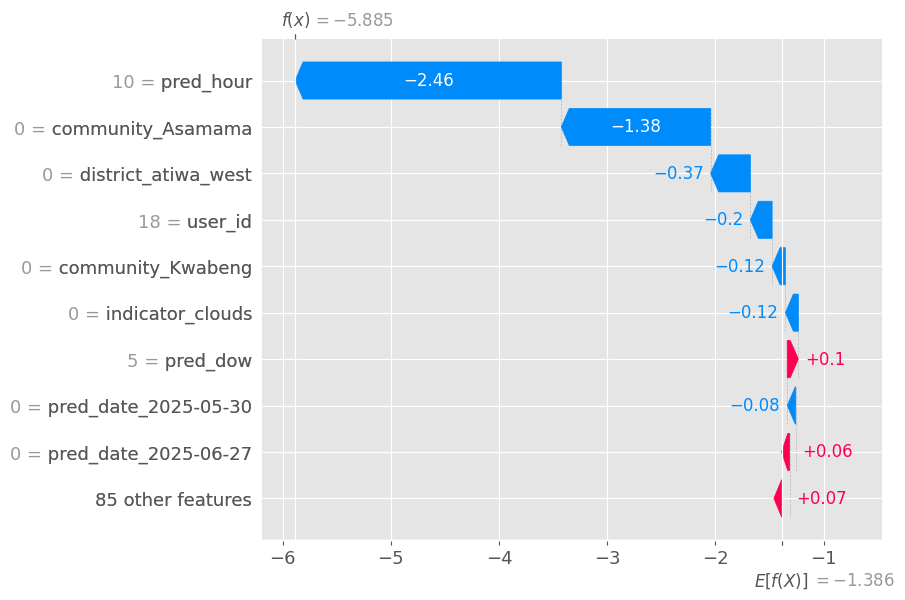


--- Explanation for MEDIUMRAIN ---


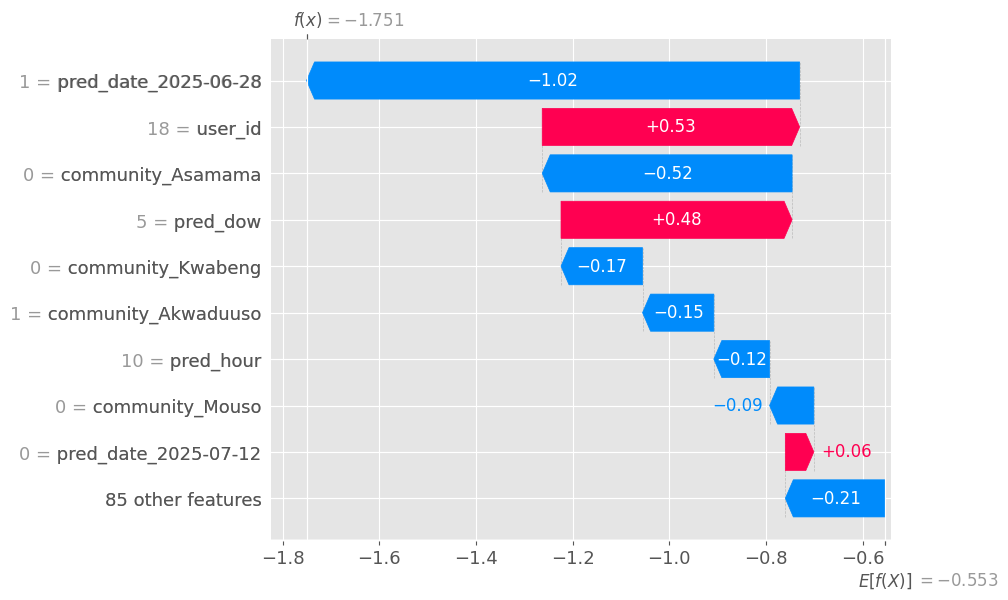


--- Explanation for NORAIN ---


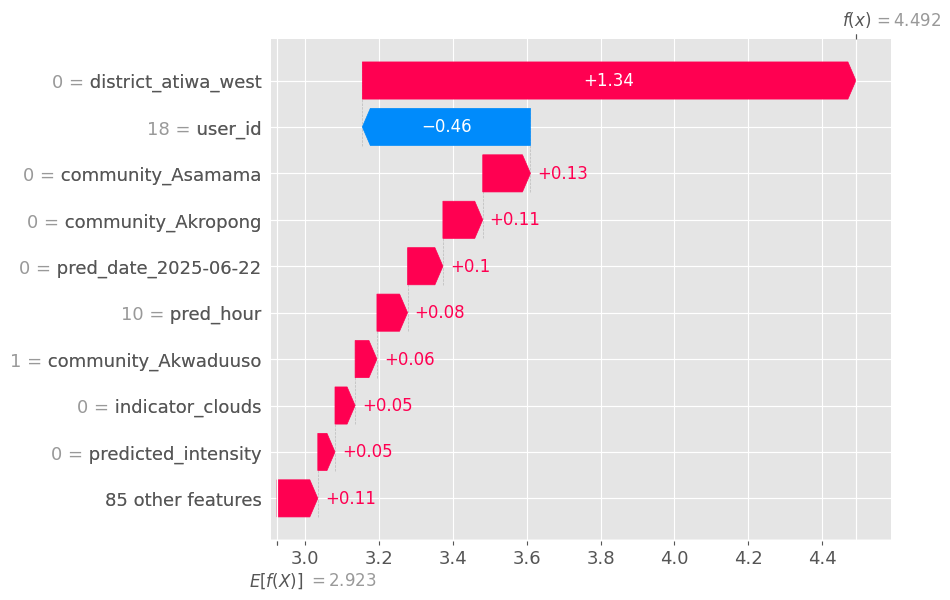


--- Explanation for SMALLRAIN ---


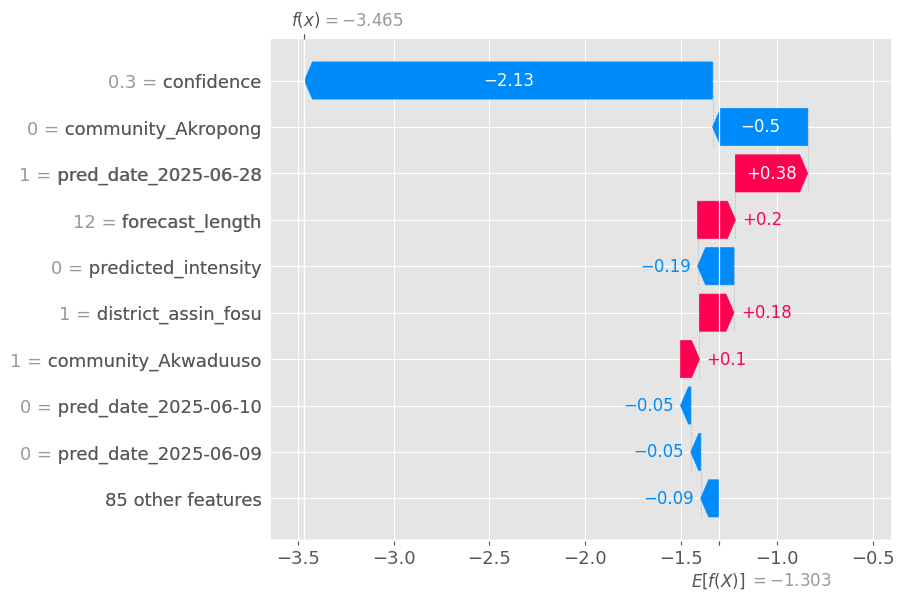

In [ ]:
# SHAP explainer
explainer = shap.TreeExplainer(final_model)
X_sample = X.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Number of classes: {len(class_names)}")

# 1. Global feature importance - WITH TEXT OUTPUT
print("\n=== GLOBAL FEATURE IMPORTANCE (TOP 10) ===")

# Handle different SHAP value formats
if isinstance(shap_values, list):
    # Multi-class: list of arrays
    shap_importance = np.mean([np.abs(sv).mean(0) for sv in shap_values], axis=0)
elif len(shap_values.shape) == 3:
    # Multi-class: 3D array (samples, features, classes)
    shap_importance = np.abs(shap_values).mean((0, 2))
elif len(shap_values.shape) == 2:
    # Binary or single class: 2D array
    if shap_values.shape[1] == len(class_names):
        # (samples, classes)
        shap_importance = np.abs(shap_values).mean((0, 1))
    else:
        # (samples, features)
        shap_importance = np.abs(shap_values).mean(0)
else:
    shap_importance = np.abs(shap_values).mean(0)

# Ensure shap_importance is 1D
shap_importance = shap_importance.reshape(-1)

feature_importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': shap_importance
}).sort_values('importance', ascending=False).head(10)

print(feature_importance_df.to_string(index=False))

# Create the plot
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=10)
plt.show()

# 2. Feature Effects Summary
print("\n=== FEATURE EFFECTS SUMMARY ===")

# Calculate summary statistics for top 10 features
top_features = feature_importance_df['feature'].head(10).tolist()

print("\nFeature Impact Directions:")

for feature in top_features:
    feature_idx = list(X_sample.columns).index(feature)

    # Get SHAP values for this feature across all samples
    if isinstance(shap_values, list):
        # Multi-class: average across classes
        feature_shap = np.mean([sv[:, feature_idx] for sv in shap_values], axis=0)
    elif len(shap_values.shape) == 3:
        # 3D array: average across classes
        feature_shap = shap_values[:, feature_idx, :].mean(axis=1)
    else:
        # 2D array
        feature_shap = shap_values[:, feature_idx]

    # Calculate correlation between feature values and SHAP values
    correlation = np.corrcoef(X_sample[feature], feature_shap)[0, 1]

    # Determine impact direction
    if correlation > 0.1:
        direction = "POSITIVE ↑"
    elif correlation < -0.1:
        direction = "NEGATIVE ↓"
    else:
        direction = "MIXED ~"

    print(f"{feature:25} {direction:12} (corr: {correlation:+.3f})")

# Create the visual plot
shap.summary_plot(shap_values, X_sample, show=False, max_display=10)
plt.show()

# 3. Waterfall plots for each class (show top 10 features)
print("\n=== INDIVIDUAL PREDICTION EXPLANATIONS (TOP 10) ===")
sample_idx = 10

for class_idx, class_name in enumerate(class_names):
    print(f"\n--- Explanation for {class_name} ---")

    # Handle different SHAP value formats
    if isinstance(shap_values, list):
        # List format
        values = shap_values[class_idx][sample_idx]
        base_value = explainer.expected_value[class_idx]
    elif len(shap_values.shape) == 3:
        # 3D array format
        values = shap_values[sample_idx, :, class_idx]
        base_value = explainer.expected_value[class_idx]
    elif len(shap_values.shape) == 2:
        # 2D array format
        if shap_values.shape[1] == len(class_names):
            values = shap_values[sample_idx, class_idx]
            base_value = explainer.expected_value[class_idx] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
        else:
            values = shap_values[sample_idx]
            base_value = explainer.expected_value
    else:
        values = shap_values[sample_idx]
        base_value = explainer.expected_value

    explanation = shap.Explanation(
        values=values,
        base_values=base_value,
        data=X_sample.iloc[sample_idx],
        feature_names=X_sample.columns.tolist()
    )

    shap.plots.waterfall(explanation, max_display=10)  # Already set to top 10
    plt.show()

GLOBAL:

The model relies mainly on user history and location. User patterns and specific communities are the strongest predictors, while actual weather indicators like clouds have little impact.

FEATURE EFFECTS:

The model shows clear directional patterns: higher values in time features (hour, day) and most communities increase rainfall predictions, while user_id and forecast_length strongly decrease them. Key weather indicators like clouds positively influence predictions as expected, but geographic and temporal factors dominate the model's decision-making.

`2. LIME`


=== LIME EXPLANATION FOR SAMPLE 25 ===
True label: NORAIN
Predicted label: NORAIN
Prediction probabilities: {'HEAVYRAIN': np.float64(0.015297355217188505), 'MEDIUMRAIN': np.float64(0.432974652098601), 'NORAIN': np.float64(0.32683997848685), 'SMALLRAIN': np.float64(0.22488801419736057)}
Intercept 0.055149269794463246
Prediction_local [0.02956619]
Right: 0.015297355217188505
Intercept 0.46336183242383555
Prediction_local [0.28085787]
Right: 0.22488801419736057
Intercept -0.16103799278990683
Prediction_local [0.47401425]
Right: 0.32683997848685
Intercept 0.2913321523643131
Prediction_local [0.28311651]
Right: 0.432974652098601

LIME EXPLANATION FOR PREDICTED CLASS: NORAIN



LIME EXPLANATIONS FOR ALL CLASSES:

--- HEAVYRAIN ---
Top features influencing HEAVYRAIN prediction:
  pred_date_2025-05-30 <= 0.00: -0.0875
  community_Asamama <= 0.00: -0.0860
  indicator_star <= 0.00: +0.0280
  15.00 < pred_hour <= 18.00: +0.0249
  pred_date_2025-06-03 <= 0.00: +0.0213
  indicator_moon <= 0.00: +0.0209
  0.00 < district_atiwa_west <= 1.00: +0.0198
  pred_date_2025-06-19 <= 0.00: +0.0190
  pred_date_2025-06-06 <= 0.00: -0.0185
  pred_date_2025-06-12 <= 0.00: +0.0179

--- MEDIUMRAIN ---
Top features influencing MEDIUMRAIN prediction:
  community_Asamama <= 0.00: -0.2207
  pred_date_2025-06-04 > 0.00: +0.1499
  pred_date_2025-06-11 <= 0.00: -0.1383
  indicator_star <= 0.00: +0.0956
  0.00 < district_atiwa_west <= 1.00: +0.0696
  indicator_moon <= 0.00: +0.0679
  pred_date_2025-06-08 <= 0.00: -0.0495
  community_Akropong > 0.00: +0.0473
  community_Kwabeng <= 0.00: -0.0467
  pred_date_2025-06-12 <= 0.00: +0.0434

--- NORAIN ---
Top features influencing NORAIN predictio

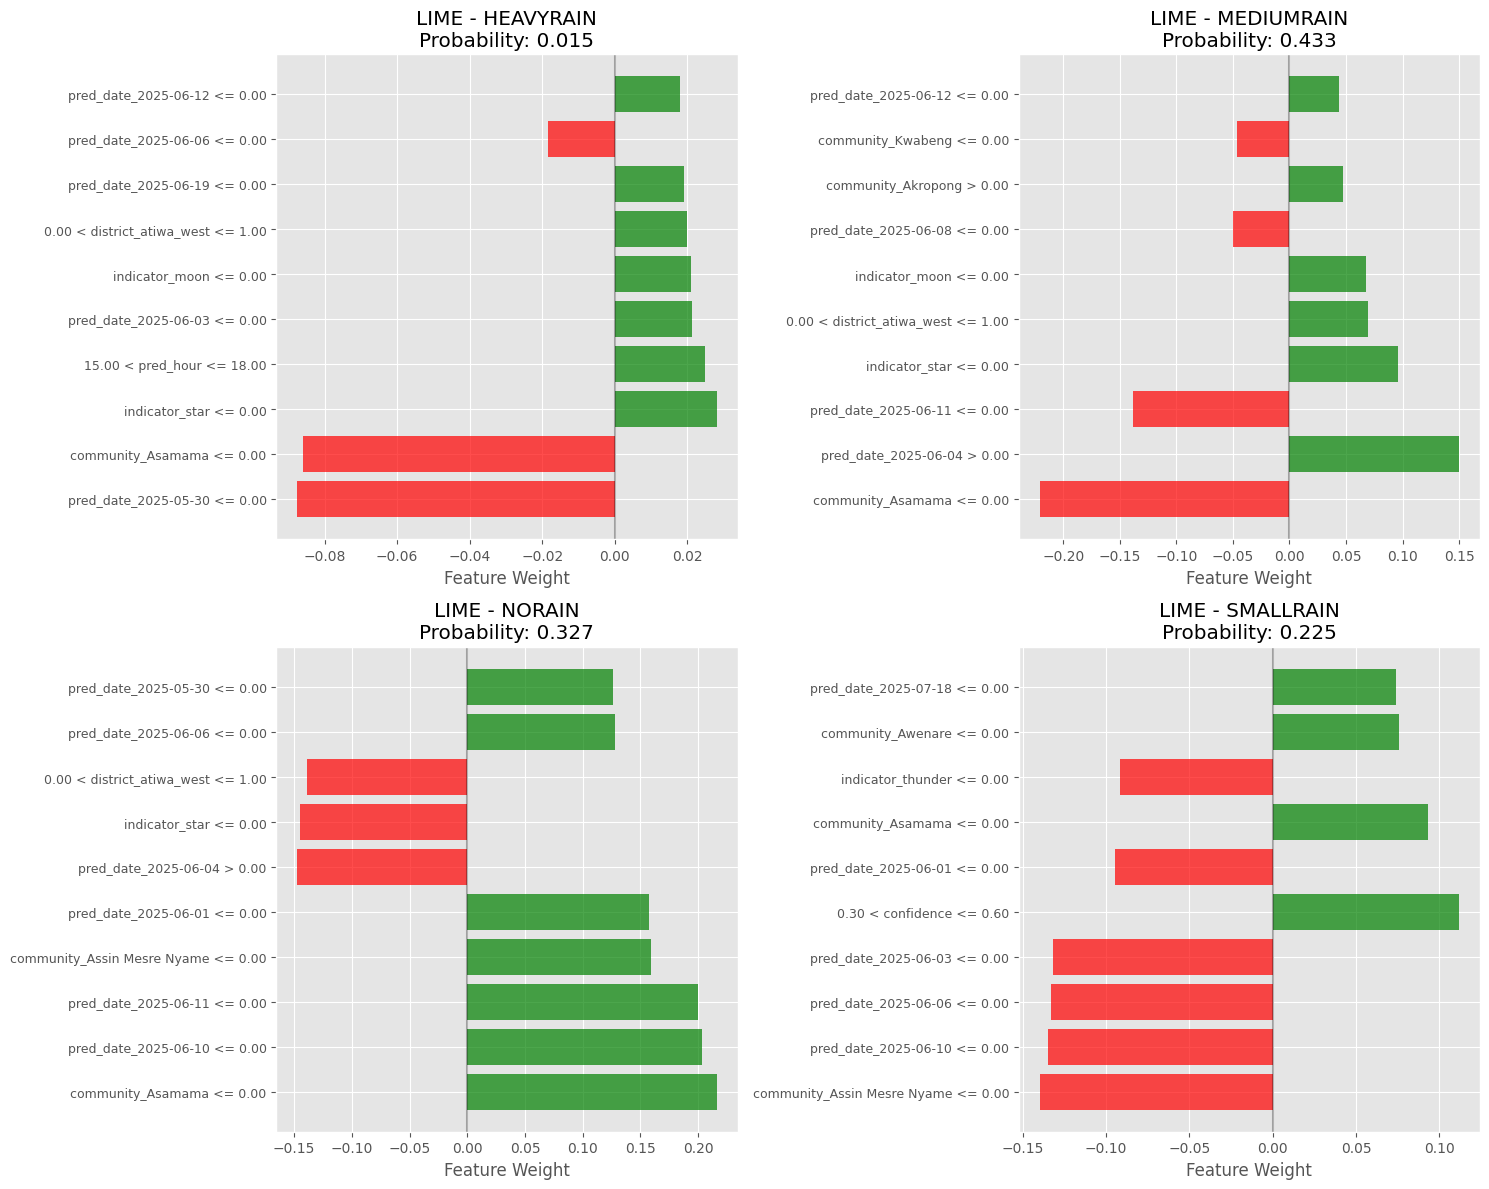

In [ ]:
# Initialize LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,  # Convert to numpy array
    feature_names=X.columns.tolist(),
    class_names=class_names,
    mode='classification',
    training_labels=y_full_numeric,
    random_state=42,
    verbose=True
)

# Select a sample to explain
sample_idx = 25 #any sample number
X_sample_to_explain = X.iloc[sample_idx].values
true_label = y.iloc[sample_idx]
predicted_label = class_names[final_model.predict(X.iloc[[sample_idx]])[0]]
predicted_proba = model.predict_proba(X.iloc[[sample_idx]])[0]

print(f"\n=== LIME EXPLANATION FOR SAMPLE {sample_idx} ===")
print(f"True label: {true_label}")
print(f"Predicted label: {predicted_label}")
print(f"Prediction probabilities: {dict(zip(class_names, predicted_proba))}")

# Define prediction function for LIME
def predict_proba_fn(x):
    """Wrapper function for model prediction"""
    return model.predict_proba(x)

# Generate LIME explanation
explanation = explainer_lime.explain_instance(
    data_row=X_sample_to_explain,
    predict_fn=predict_proba_fn,
    num_features=15,  # Show top 15 features
    top_labels=len(class_names)  # Explain all classes
)

# === VISUALIZE LIME EXPLANATIONS ===

# 1. Show explanation for the predicted class
print(f"\nLIME EXPLANATION FOR PREDICTED CLASS: {predicted_label}")
explanation.show_in_notebook(show_table=True, show_all=False)

# 2. Show explanations for all classes
print(f"\nLIME EXPLANATIONS FOR ALL CLASSES:")
for class_idx, class_name in enumerate(class_names):
    print(f"\n--- {class_name} ---")
    temp_exp = explanation.as_list(label=class_idx)
    print(f"Top features influencing {class_name} prediction:")
    for feature, weight in temp_exp[:10]:  # Show top 10
        print(f"  {feature}: {weight:+.4f}")

# 3. Create matplotlib visualization
print(f"\n LIME VISUALIZATION ")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for class_idx, class_name in enumerate(class_names):
    if class_idx < 4:  # For the 4 classes
        # Get explanation for this class
        exp_list = explanation.as_list(label=class_idx)

        # Take top 10 features
        features = [x[0] for x in exp_list[:10]]
        weights = [x[1] for x in exp_list[:10]]

        # Create horizontal bar plot
        y_pos = np.arange(len(features))
        colors = ['green' if w > 0 else 'red' for w in weights]

        axes[class_idx].barh(y_pos, weights, color=colors, alpha=0.7)
        axes[class_idx].set_yticks(y_pos)
        axes[class_idx].set_yticklabels(features, fontsize=9)
        axes[class_idx].set_xlabel('Feature Weight')
        axes[class_idx].set_title(f'LIME - {class_name}\nProbability: {predicted_proba[class_idx]:.3f}')
        axes[class_idx].axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout();

# 4. Detailed analysis for the predicted class
predicted_class_idx = np.argmax(predicted_proba)
print(f"\n DETAILED ANALYSIS FOR PREDICTED CLASS: {class_names[predicted_class_idx]}")
exp_list = explanation.as_list(label=predicted_class_idx)

print("Features SUPPORTING this prediction (positive weights):")

for feature, weight in exp_list:
    if weight > 0:
        feature_name = feature.split(' <= ')[0] if ' <= ' in feature else feature.split(' > ')[0]
        original_value = X.iloc[sample_idx][feature_name] if feature_name in X.columns else "N/A"
        print(f"  + {feature}: {weight:+.4f} (value: {original_value})")

print("\nFeatures OPPOSING this prediction (negative weights):")
print("-" * 50)
for feature, weight in exp_list:
    if weight < 0:
        feature_name = feature.split(' <= ')[0] if ' <= ' in feature else feature.split(' > ')[0]
        original_value = X.iloc[sample_idx][feature_name] if feature_name in X.columns else "N/A"
        print(f"  - {feature}: {weight:+.4f} (value: {original_value})")

In [ ]:
# Use LIME to understand model behavior patterns
print("=== LIME MODEL BEHAVIOR ANALYSIS ===")

# Analyze what drives different rain type predictions
rain_type_drivers = {}

for rain_type in class_names:
    print(f"\n What drives {rain_type} predictions?")

    # Find samples predicted as this type with high confidence
    predictions = final_model.predict(X)
    predicted_labels = label_encoder.inverse_transform(predictions)
    probabilities = model.predict_proba(X)

    high_conf_indices = np.where(
        (predicted_labels == rain_type) &
        (probabilities[np.arange(len(probabilities)), predictions] > 0.8)
    )[0]

    if len(high_conf_indices) > 0:
        # Analyze a few high-confidence samples
        sample_idx = high_conf_indices[0]
        explanation = explainer_lime.explain_instance(
            data_row=X.iloc[sample_idx].values,
            predict_fn=predict_proba_fn,
            num_features=8,
            top_labels=1
        )

        rain_type_idx = list(class_names).index(rain_type)
        top_features = explanation.as_list(label=rain_type_idx)[:3]

        print(f"High-confidence sample (Index {sample_idx}):")
        for feature, weight in top_features:
            if weight > 0:  # Only show supporting features
                print(f"  • {feature}: +{weight:.3f}")

        rain_type_drivers[rain_type] = [f[0] for f in top_features if f[1] > 0]
    else:
        print(f"  No high-confidence {rain_type} predictions found")

print("\n SUMMARY: Key drivers for each rain type")

for rain_type, drivers in rain_type_drivers.items():
    print(f"{rain_type}: {', '.join(drivers[:3])}")

=== LIME MODEL BEHAVIOR ANALYSIS ===

 What drives HEAVYRAIN predictions?
Intercept 0.17210600317247962
Prediction_local [0.20636312]
Right: 0.8766921384796862
High-confidence sample (Index 7):
  • pred_date_2025-05-30 > 0.00: +0.130

 What drives MEDIUMRAIN predictions?
Intercept 0.3342556387779479
Prediction_local [0.39472983]
Right: 0.8657626847686025
High-confidence sample (Index 194):
  • pred_date_2025-06-11 > 0.00: +0.234
  • user_id <= 20.00: +0.090

 What drives NORAIN predictions?
Intercept -0.17190678053083064
Prediction_local [0.7545536]
Right: 0.9091689398902282
High-confidence sample (Index 26):
  • pred_date_2025-06-10 <= 0.00: +0.231
  • community_Asamama <= 0.00: +0.205
  • pred_date_2025-06-11 <= 0.00: +0.160

 What drives SMALLRAIN predictions?
Intercept 0.25050382825790096
Prediction_local [0.48089844]
Right: 0.9339888886872457
High-confidence sample (Index 19):
  • pred_date_2025-06-03 > 0.00: +0.213
  • 0.30 < confidence <= 0.60: +0.107

 SUMMARY: Key drivers for 

## 8.Model Prediction

In [ ]:
# For test set, used the processed test features
test_features_processed = test_pro

# Predict on test set
test_pred_numeric = final_model.predict(test_features_processed)
test_pred = label_encoder.inverse_transform(test_pred_numeric)


In [ ]:
# Convert to ONNX with feature name handling

# Get the number of features
n_features = X_features.shape[1]
print(f" Number of features: {n_features}")

def convert_xgboost_fixed(model, n_features, model_name="ghana_rainfall_final.onnx"):
    """
    Fixed conversion method with feature name standardization
    """
    try:
        # Create a temporary model with standardized feature names
        temp_model = xgb.XGBClassifier()
        temp_model = model  # We'll work with the original model

        # Standardize feature names to f0, f1, f2 format
        standard_feature_names = [f'f{i}' for i in range(n_features)]

        # Update the model's feature names
        if hasattr(temp_model, 'get_booster'):
            booster = temp_model.get_booster()
            booster.feature_names = standard_feature_names
        elif hasattr(temp_model, 'feature_names_in_'):
            # For newer XGBoost versions
            temp_model.feature_names_in_ = standard_feature_names

        # Define input type using standardized feature names
        initial_type = [('float_input', FloatTensorType([None, n_features]))]

        print(f" Converting XGBoost model to ONNX...")
        print(f" Input shape: (batch_size, {n_features})")
        print(f" Using standardized feature names: f0 to f{n_features-1}")

        # Convert the model
        onnx_model = convert_xgboost(temp_model, initial_types=initial_type)

        # Save the ONNX model
        with open(model_name, "wb") as f:
            f.write(onnx_model.SerializeToString())

        print(f" XGBoost model converted successfully!")
        print(f" Saved as: {model_name}")

        return onnx_model

    except Exception as e:
        print(f" Conversion failed: {e}")
        return None

# Alternative solution: Create feature mapping for future reference
def create_feature_mapping(original_features, standard_features):
    """Create mapping between original and standardized feature names"""
    feature_mapping = dict(zip(original_features, standard_features))
    return feature_mapping

# Convert the model with fixed feature names
onnx_model = convert_xgboost_fixed(final_model, n_features, "ghana_rainfall_final.onnx")

# Create feature mapping for documentation
if onnx_model:
    standard_features = [f'f{i}' for i in range(n_features)]
    feature_mapping = create_feature_mapping(X_features.columns.tolist(), standard_features)

    # Save feature mapping for future reference
    import json
    with open('feature_mapping.json', 'w') as f:
        json.dump(feature_mapping, f, indent=2)
    print("📋 Feature mapping saved to 'feature_mapping.json'")

 Number of features: 94
 Converting XGBoost model to ONNX...
 Input shape: (batch_size, 94)
 Using standardized feature names: f0 to f93
 XGBoost model converted successfully!
 Saved as: ghana_rainfall_final.onnx
📋 Feature mapping saved to 'feature_mapping.json'


## 9.Submission

In [ ]:
# View sample submission
sample_sub = pd.read_csv('SampleSubmission.csv')
display(sample_sub.head())

,ID,Target
0,ID_TxqKq_24,SMALLRAIN
1,ID_8PP4P_12,SMALLRAIN
2,ID_DkPcN_12,SMALLRAIN
3,ID_lxUih_24,SMALLRAIN
4,ID_33KM9_12,SMALLRAIN


In [ ]:
# Create submission using the original test DataFrame's IDs
submission = pd.DataFrame({
    'ID': test['ID'].values,
    'Target': test_pred
})

print('\n SUBMISSION INFO ')
print(f'Submission shape: {submission.shape}')
print('Prediction distribution:')
print(submission['Target'].value_counts())

# Save submission to CSV
submission_file = 'submission_xgb.csv'
submission.to_csv(submission_file, index=False)
print(f'\n Submission saved to: {submission_file}')
print(submission.head())


 SUBMISSION INFO 
Submission shape: (2732, 2)
Prediction distribution:
Target
NORAIN        2505
MEDIUMRAIN     126
HEAVYRAIN       83
SMALLRAIN       18
Name: count, dtype: int64

 Submission saved to: submission_xgb.csv
            ID  Target
0  ID_SbTdy_24  NORAIN
1  ID_SBKYz_24  NORAIN
2  ID_fAimg_24  NORAIN
3  ID_2wBqC_24  NORAIN
4  ID_NItox_24  NORAIN


In [ ]:
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60
print(f"Notebook run time: {elapsed_minutes:.1f} minutes")

Notebook run time: 1.1 minutes
